# Recursive Classical Reservoir Computing

In [1]:
# Import packages
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [3]:
# Level 1 data
ds_level1 = load_dataset(
    "Quandela/Challenge_Swaptions",
    data_files="level-1_Future_prediction/train.csv",
    split="train"
)

# Convert to pandas DataFrame
df_level1 = ds_level1.to_pandas()

In [4]:
# -------------------------------------------------
# 1. Prepare Data
# -------------------------------------------------

df = df_level1.copy()

# Ensure correct date ordering
df["Date"] = pd.to_datetime(df["Date"], format='%d/%m/%Y')
df = df.sort_values("Date").reset_index(drop=True)

# Drop Date column
price_df = df.drop(columns=["Date"])

prices = price_df.values  # shape (T, 224)

# Log transform
log_prices = np.log(prices)

# -------------------------------------------------
# 2. Train / Validation Split (chronological)
# -------------------------------------------------

T = len(log_prices)

train_data = log_prices[:int(T * 0.75), :]
val_data = log_prices[int(T * 0.75):, :]

In [5]:
# -------------------------------------------------
# 3. Scale (fit only on training)
# -------------------------------------------------

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
val_scaled = scaler.transform(val_data)

In [6]:
# -------------------------------------------------
# 4. PCA (fit only on training)
# -------------------------------------------------

K = 5
pca = PCA(n_components=K)

train_factors = pca.fit_transform(train_scaled)
val_factors = pca.transform(val_scaled)

(334, 30, 5)
(334, 6, 5)
Train RMSE: 0.011630799606411047
Train MAPE: 4.148329528379067
Validation RMSE: 0.009279297565918042
Validation MAPE: 3.859814236686807


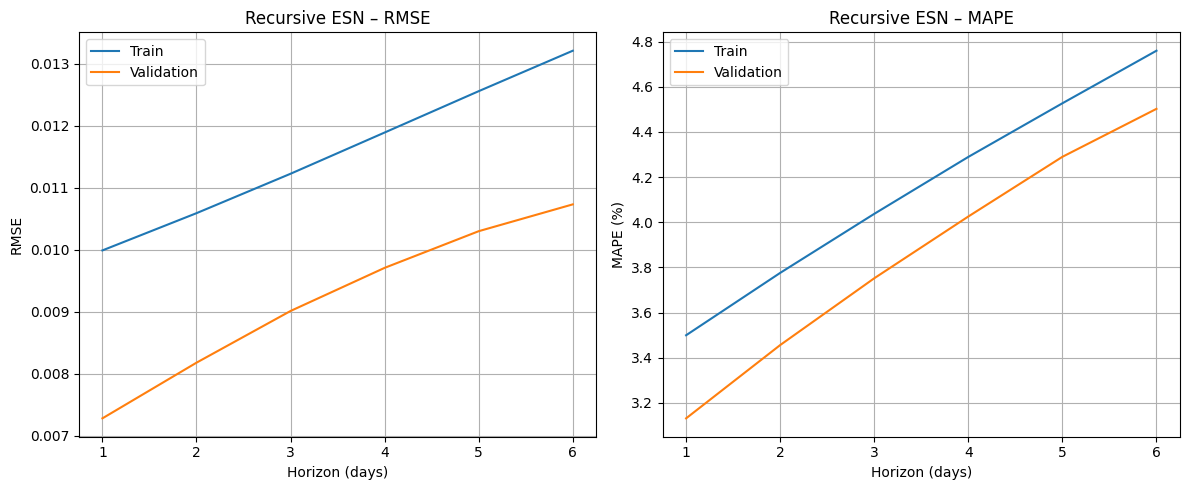

In [7]:
WINDOW = 30
HORIZON = 6

def create_recursive_windows(data):
    """
    Returns:
        X : (n_samples, WINDOW, K)
        Y : (n_samples, HORIZON, K)
    """
    X, Y = [], []

    for t in range(WINDOW, len(data) - HORIZON):
        X.append(data[t-WINDOW:t])
        Y.append(data[t:t+HORIZON])

    return np.array(X), np.array(Y)


X_train, Y_train = create_recursive_windows(train_factors)
X_val, Y_val = create_recursive_windows(val_factors)

print(X_train.shape)  # (n_samples, 60, K)
print(Y_train.shape)  # (n_samples, 6, K)

def create_one_step_data(data):
    X, Y = [], []
    for t in range(WINDOW, len(data) - 1):
        X.append(data[t-WINDOW:t])
        Y.append(data[t])
    return np.array(X), np.array(Y)

X_train_1, Y_train_1 = create_one_step_data(train_factors)

import numpy as np

class ESN:
    def __init__(self, input_dim, reservoir_dim=400,
                 spectral_radius=0.7,
                 sparsity=0.1,
                 leak=0.2,
                 ridge=10000):

        self.input_dim = input_dim
        self.reservoir_dim = reservoir_dim
        self.leak = leak
        self.ridge = ridge

        self.Win = np.random.uniform(-1, 1,
                                     (reservoir_dim, input_dim))

        W = np.random.uniform(-1, 1,
                              (reservoir_dim, reservoir_dim))

        mask = np.random.rand(*W.shape) < sparsity
        W *= mask

        eigvals = np.linalg.eigvals(W)
        W *= spectral_radius / np.max(np.abs(eigvals))

        self.W = W

    def run_reservoir(self, U, state=None):

        if state is None:
            state = np.zeros(self.reservoir_dim)

        for u in U:
            x = np.tanh(self.Win @ u + self.W @ state)
            state = (1 - self.leak)*state + self.leak*x

        return state

    def fit(self, X, Y):

        states = []

        for sample in X:
            final_state = self.run_reservoir(sample)
            states.append(final_state)

        states = np.array(states)

        I = np.eye(self.reservoir_dim)
        self.Wout = np.linalg.inv(
            states.T @ states + self.ridge * I
        ) @ states.T @ Y

    def predict_one(self, window):

        state = self.run_reservoir(window)
        return state @ self.Wout, state

esn = ESN(input_dim=K)
esn.fit(X_train_1, Y_train_1)

def recursive_forecast(esn, window, horizon=6):

    preds = []
    state = esn.run_reservoir(window)

    for _ in range(horizon):

        next_pred = state @ esn.Wout
        preds.append(next_pred)

        # update state using predicted value
        x = np.tanh(esn.Win @ next_pred + esn.W @ state)
        state = (1 - esn.leak)*state + esn.leak*x

    return np.array(preds)

def generate_predictions(esn, X, horizon=6):

    all_preds = []

    for window in X:
        preds = recursive_forecast(esn, window, horizon)
        all_preds.append(preds)

    return np.array(all_preds)


train_pred = generate_predictions(esn, X_train)
val_pred = generate_predictions(esn, X_val)

def reconstruct(pred):

    n_samples = pred.shape[0]

    pred_flat = pred.reshape(-1, K)

    log_scaled = pca.inverse_transform(pred_flat)
    log_prices = scaler.inverse_transform(log_scaled)
    prices = np.exp(log_prices)

    return prices.reshape(n_samples, HORIZON, -1)

def compute_overall_metrics(pred, true, eps=1e-8):

    pred_prices = reconstruct(pred)
    true_prices = reconstruct(true)

    mse = np.mean((pred_prices - true_prices)**2)
    rmse = np.sqrt(mse)

    mape = np.mean(
        np.abs((pred_prices - true_prices) /
               (true_prices + eps))
    ) * 100

    return rmse, mape


train_rmse, train_mape = compute_overall_metrics(train_pred, Y_train)
val_rmse, val_mape = compute_overall_metrics(val_pred, Y_val)

print("Train RMSE:", train_rmse)
print("Train MAPE:", train_mape)
print("Validation RMSE:", val_rmse)
print("Validation MAPE:", val_mape)

def compute_horizon_metrics(pred, true, eps=1e-8):

    pred_prices = reconstruct(pred)
    true_prices = reconstruct(true)

    rmse_h = []
    mape_h = []

    for h in range(HORIZON):

        pred_h = pred_prices[:, h, :]
        true_h = true_prices[:, h, :]

        mse = np.mean((pred_h - true_h)**2)
        rmse = np.sqrt(mse)

        mape = np.mean(
            np.abs((pred_h - true_h) /
                   (true_h + eps))
        ) * 100

        rmse_h.append(rmse)
        mape_h.append(mape)

    return np.array(rmse_h), np.array(mape_h)


train_rmse_h, train_mape_h = compute_horizon_metrics(train_pred, Y_train)
val_rmse_h, val_mape_h = compute_horizon_metrics(val_pred, Y_val)

import matplotlib.pyplot as plt
import numpy as np

horizon = np.arange(1, HORIZON + 1)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(horizon, train_rmse_h, label="Train")
plt.plot(horizon, val_rmse_h, label="Validation")
plt.xlabel("Horizon (days)")
plt.ylabel("RMSE")
plt.title("Recursive ESN – RMSE")
plt.legend()
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(horizon, train_mape_h, label="Train")
plt.plot(horizon, val_mape_h, label="Validation")
plt.xlabel("Horizon (days)")
plt.ylabel("MAPE (%)")
plt.title("Recursive ESN – MAPE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()